In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/DV/studentperformance_preprocessed.csv')

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_mark,percentage
0,female,group b,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group c,some college,standard,completed,69,90,88,247,82.333333
2,female,group b,master's degree,standard,none,90,95,93,278,92.666667
3,male,group a,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group c,some college,standard,none,76,78,75,229,76.333333


In [6]:
df["total_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

df["average_score"] = df["total_score"] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_mark,percentage,total_score,average_score
0,female,group b,bachelor's degree,standard,none,72,72,74,218,72.666667,218,72.666667
1,female,group c,some college,standard,completed,69,90,88,247,82.333333,247,82.333333
2,female,group b,master's degree,standard,none,90,95,93,278,92.666667,278,92.666667
3,male,group a,associate's degree,free/reduced,none,47,57,44,148,49.333333,148,49.333333
4,male,group c,some college,standard,none,76,78,75,229,76.333333,229,76.333333



Average scores by parental education:


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


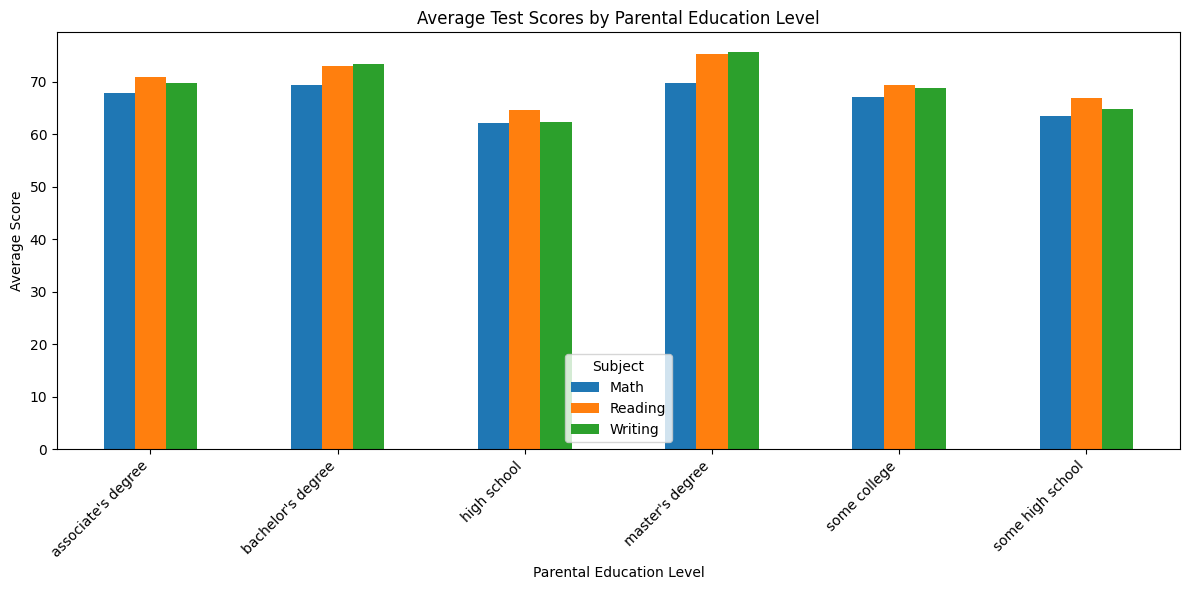

In [8]:
parental_avg = df.groupby("parental level of education")[
    ["math score", "reading score", "writing score"]
].mean()

print("\nAverage scores by parental education:")
display(parental_avg)

parental_avg.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Test Scores by Parental Education Level")
plt.xlabel("Parental Education Level")
plt.ylabel("Average Score")
plt.xticks(rotation=45, ha="right")
plt.legend(
    title="Subject",
    labels=["Math", "Reading", "Writing"]
)
plt.tight_layout()
plt.show()


Average scores by lunch type:


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


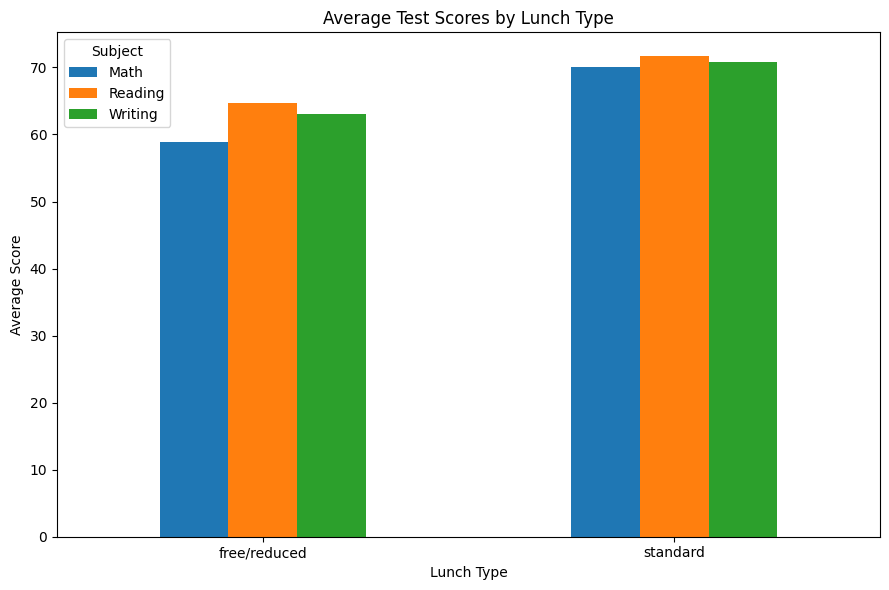

In [9]:

lunch_avg = df.groupby("lunch")[
    ["math score", "reading score", "writing score"]
].mean()

print("\nAverage scores by lunch type:")
display(lunch_avg)

lunch_avg.plot(
    kind="bar",
    figsize=(9, 6)
)

plt.title("Average Test Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.legend(
    title="Subject",
    labels=["Math", "Reading", "Writing"]
)
plt.tight_layout()
plt.show()

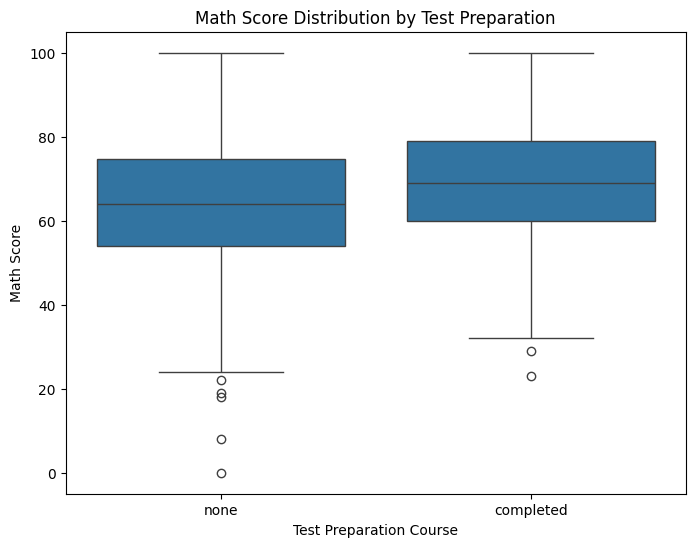

In [10]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="math score"
)

plt.title("Math Score Distribution by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Math Score")
plt.show()

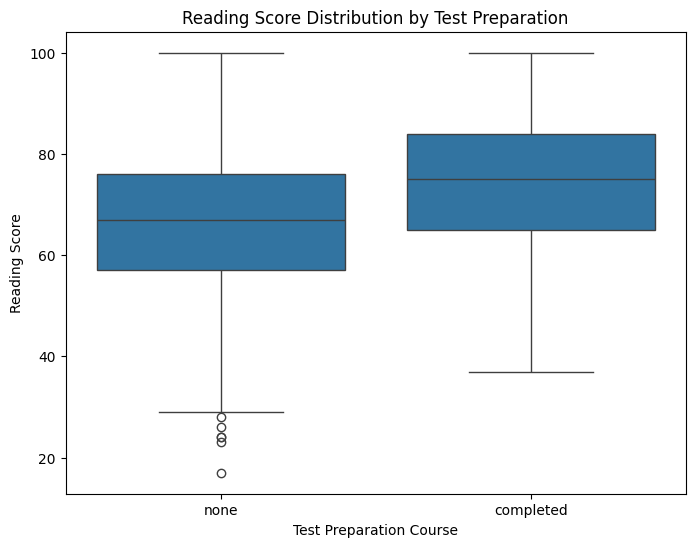

In [11]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="reading score"
)

plt.title("Reading Score Distribution by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Reading Score")
plt.show()

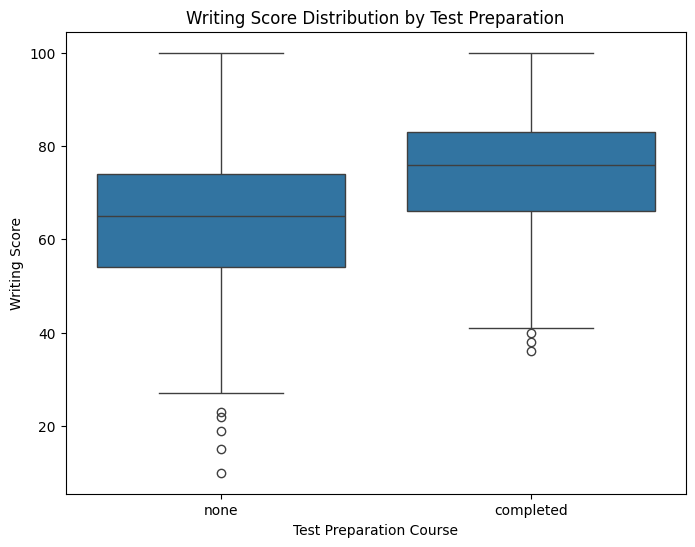

In [12]:

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="test preparation course",
    y="writing score"
)

plt.title("Writing Score Distribution by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Writing Score")
plt.show()

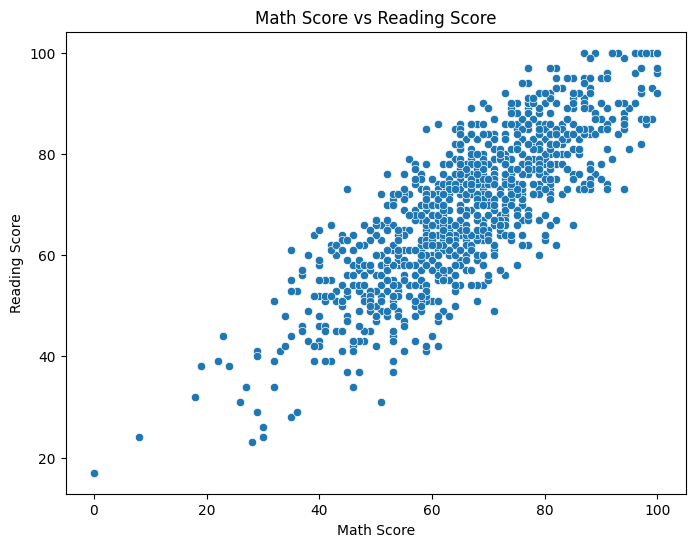

In [13]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="math score",
    y="reading score"
)

plt.title("Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

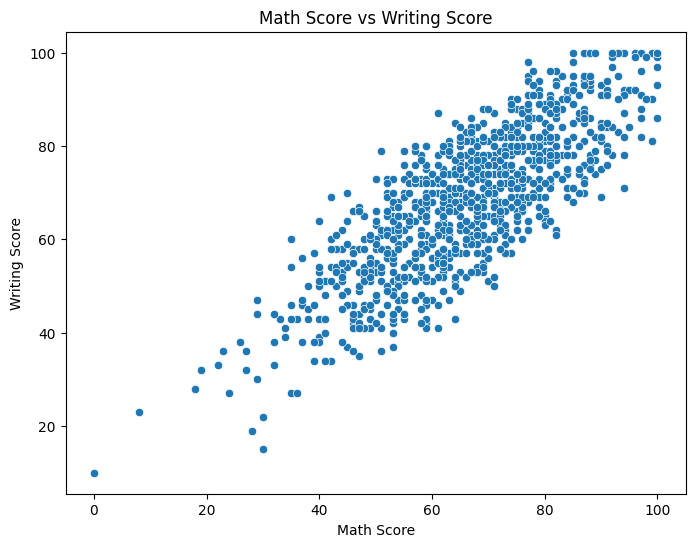

In [14]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="math score",
    y="writing score"
)

plt.title("Math Score vs Writing Score")
plt.xlabel("Math Score")
plt.ylabel("Writing Score")
plt.show()

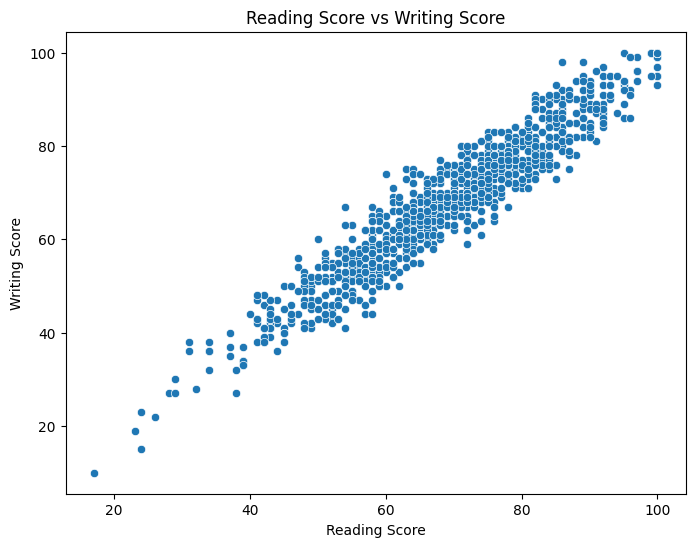

In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="reading score",
    y="writing score"
)

plt.title("Reading Score vs Writing Score")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.show()


Correlation Matrix:


,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


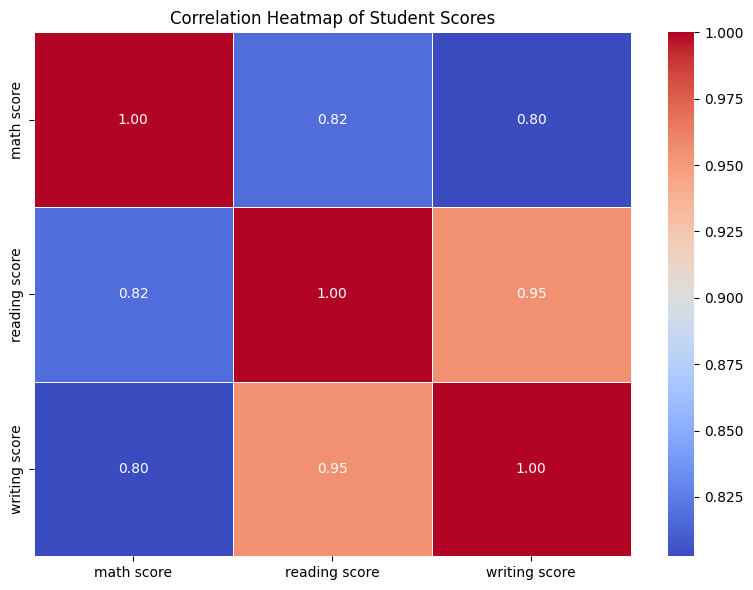

In [16]:
score_columns = [
    "math score",
    "reading score",
    "writing score"
]

correlation = df[score_columns].corr()

print("\nCorrelation Matrix:")
display(correlation)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Student Scores")
plt.tight_layout()
plt.show()

In [17]:

prep_avg = df.groupby("test preparation course")[
    ["math score", "reading score", "writing score"]
].mean()

print("\nAverage scores by test preparation:")
display(prep_avg)


Average scores by test preparation:


,math score,reading score,writing score
test preparation course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [18]:
print("\nLunch type comparison:")
display(
    df.groupby("lunch")[
        ["math score", "reading score", "writing score"]
    ].mean()
)



Lunch type comparison:


,math score,reading score,writing score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [19]:

print("\nParental education comparison:")
display(
    df.groupby("parental level of education")[
        ["math score", "reading score", "writing score"]
    ].mean()
)



Parental education comparison:


,math score,reading score,writing score
parental level of education,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268
